**Supervised Learning**

Definition:
In Supervised Learning, the model is trained using labeled data. This means each input data already has the correct output (label).

The model learns the relationship between input (X) and output (Y).

Example:

Input: Email text

Output: Spam or Not Spam

The model learns from many examples and then predicts for new emails.

**Common Tasks:-**

**Classification** – Predict categories

Example: Spam detection

**Regression** – Predict numerical values

Example: House price prediction

**Popular Algorithms**

Linear Regression

Logistic Regression

Decision Trees

Random Forest

Support Vector Machine (SVM)

Neural Networks

**Unsupervised Learning**

Definition:
In Unsupervised Learning, the model is trained with unlabeled data. There are no correct outputs provided.

The algorithm tries to discover hidden patterns or structures in the data.

Example:
A company has customer data but no labels. The algorithm groups customers based on similar behavior.

**Common Tasks :-**

**Clustering** – Group similar data points

**Association** – Find relationships between items

Popular Algorithms

K-Means Clustering

Hierarchical Clustering

DBSCAN

Apriori Algorithm

Principal Component Analysis (PCA)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**simple linear regression**

---



**importing the dataset**

In [ ]:
dataset = pd.read_csv("/content/Book13.csv")
x = dataset.iloc[ : , : -1].values
y = dataset.iloc[ : , -1].values
#print(dataset)
#print(x)
#print(y)

**splitting the dataset into the training set and test set**

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

**training the simple linear regression model on the training set**

In [ ]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_train, y_train)



LinearRegression()

**regressor.fit(x_train, y_train) is used to train the linear regression model using the training dataset, where x_train is the input feature and y_train is the target variable.**

It adjusts the model parameters so the model can make accurate predictions.

Reads the dataset.
Finds patterns between X and y.
Calculates optimal model parameters.
 Stores the trained model for prediction.

**predicting the test set result**

In [ ]:
y_pred = regressor.predict(x_test)

**y_pred = regressor.predict(x_test) is used to generate predicted values for the test dataset using the trained linear regression model. Here x_test contains input values and y_pred stores the predicted outputs.**

**visualising the training set results**

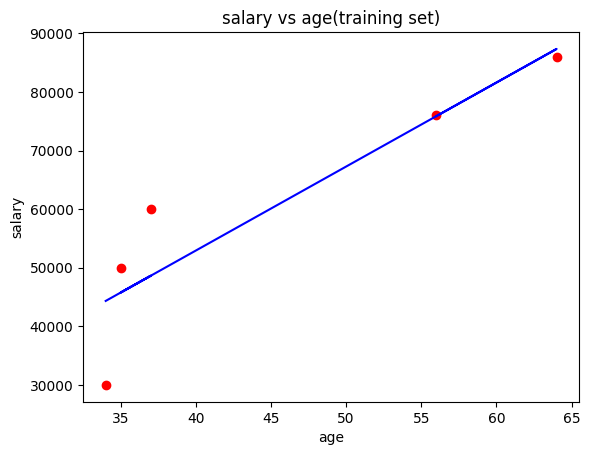

In [ ]:
plt.scatter(x_train, y_train, color = 'red')
plt.plot(x_train,  regressor.predict(x_train), color = 'blue')
plt.title('salary vs age(training set)')
plt.xlabel('age')
plt.ylabel('salary')
plt.show()

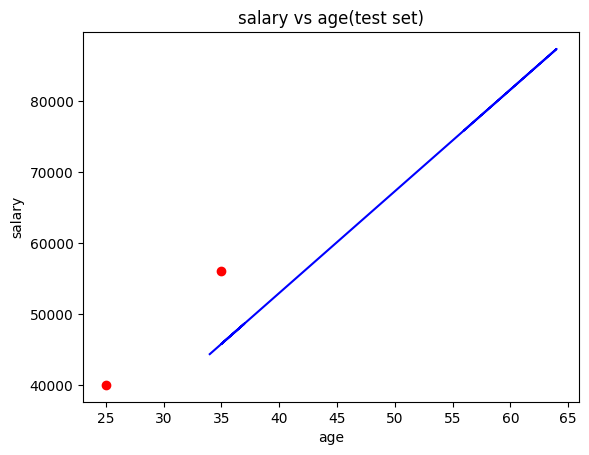

In [ ]:
plt.scatter(x_test, y_test, color = 'red')
plt.plot(x_train,  regressor.predict(x_train), color = 'blue')
plt.title('salary vs age(test set)')
plt.xlabel('age')
plt.ylabel('salary')
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
#Imports the LinearRegression class from Scikit-learn.
#This class is used to build and train the regression model.

from sklearn.metrics import mean_squared_error, r2_score
#Imports evaluation metrics used to measure model performance.
#Metrics used:
#mean_squared_error (MSE) → measures prediction error
#r2_score (R²) → measures how well the model fits the data

import numpy as np
X = np.array([[1], [2], [3], [4], [5]])
#X represents the independent variable (input).
#Here it represents study hours.

y = np.array([35, 50, 55, 70, 80])
#y represents the dependent variable (output).
#Here it represents exam scores.

model = LinearRegression()
#Creates an object of LinearRegression model.
#This object will learn the relationship between study hours and exam score.

model.fit(X, y)
#fit() trains the model using the dataset.
#The algorithm calculates:
#Slope (β₁)
#Intercept (β₀)

print(f"Intercept  (beta_0): {model.intercept_:.2f}")
#model.intercept_ gives the intercept value.
#Intercept = predicted score when study hours = 0.

print(f"Slope (beta_1): {model.coef_[0]:.2f}")
#model.coef_ gives the slope (coefficient).
#[0] selects the first feature coefficient.

y_pred = model.predict(X)
#predict() calculates predicted scores using the learned equation.
#Predictions are made for the same dataset X.

print(f"\nPredictions : {y_pred}")
print(f"Actuals     : {y}")
#Prints predicted scores and actual scores.
#Helps compare model performance.

print(f"\nMSE : {mean_squared_error(y, y_pred):.2f}")
#Measures the average squared difference between actual and predicted values.
#Lower MSE = better model.

print(f"R2 : {r2_score(y, y_pred):.4f}")
#Measures how well the model explains variance.

new_hours = np.array([[6]])
print(f"\nPredicted score for 6 hrs: {model.predict(new_hours)[0]:.1f}")


Intercept  (beta_0): 25.00
Slope (beta_1): 11.00

Predictions : [36. 47. 58. 69. 80.]
Actuals     : [35 50 55 70 80]

MSE : 4.00
R2 : 0.9837

Predicted score for 6 hrs: 91.0


**Multiple linear regression**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
X = np.array([
    [2, 6, 6.5], [3, 7, 7.0], [5, 8, 7.5],
    [7, 6, 8.0], [8, 9, 8.5], [4, 7, 7.2],
    [6, 8, 7.8], [9, 7, 9.0], [1, 5, 6.0], [5, 6, 7.0]
])
y = np.array([50, 60, 75, 85, 92, 65, 80, 95, 40, 70])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LinearRegression()
model.fit(X_train_scaled, y_train)
feature_names = ['study_hours', 'sleep_hours', 'prev_gpa']
print("Intercept:", round(model.intercept_, 2))
for name, coef in zip(feature_names, model.coef_):
    print(f"  {name:15s}: {coef:.2f}")
y_pred = model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\nTest RMSE : {rmse:.2f}")
print(f"Test R2   : {r2_score(y_test, y_pred):.4f}")
new_student = scaler.transform([[6, 8, 7.8]])
print(f"\nPredicted score: {model.predict(new_student)[0]:.1f}")



Intercept: 76.5
  study_hours    : 14.93
  sleep_hours    : 1.64
  prev_gpa       : -1.89

Test RMSE : 2.82
Test R2   : 0.9204

Predicted score: 79.4


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = np.array([
    [2, 60, 5],
    [4, 70, 6],
    [6, 80, 8],
    [8, 90, 9],
    [3, 65, 6],
    [7, 85, 8]
])

y = np.array([50, 60, 75, 90, 55, 85])

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
print("Predicted Marks:", model.predict(scaler.transform([[5, 75, 7]]))[0])

Predicted Marks: 67.5


a.fit()
Calculates:
mean (μ)
std (σ)

 b. transform()
Applies formula:

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = np.array([
    [100, 20, 10],
    [200, 30, 20],
    [300, 40, 30],
    [150, 25, 15],
    [250, 35, 25]
])

y = np.array([10, 20, 30, 15, 25])

model = LinearRegression()
model.fit(X, y)

print("Predicted Sales:", model.predict([[220, 33, 18]])[0])

Predicted Sales: 21.97058823529412


**How to handle Categorical variables in Linear Regression Models**


Handling categorical variables in linear regression is very important, because regression models understand only numbers, not text like “Red”, “Male”, “City A”, etc.

1.Regression needs numbers

2.Categories must be converted

3.Best method → One-Hot Encoding

 4.Drop one column to avoid multicollinearity

 5.Use ordinal encoding only when order exists

 Dummy Variable Trap occurs when all dummy variables are included, causing perfect multicollinearity and making the model unstable.

 Always use drop_first=True → avoids dummy trap

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Dataset
data = pd.DataFrame({
    'Job': ['Engineer', 'Doctor', 'Teacher', 'Engineer', 'Doctor'],
    'Salary': [60000, 80000, 40000, 65000, 85000]
})

# One-hot encoding (drop first to avoid dummy trap)
X = pd.get_dummies(data['Job'], drop_first=True)
y = data['Salary']

# Model
model = LinearRegression()
model.fit(X, y)

print("Intercept (b0):", model.intercept_)
print("Coefficients:", model.coef_)

Intercept (b0): 82500.00000000001
Coefficients: [-20000. -42500.]


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
data = pd.DataFrame({
    'R&D': [165000,162000,153000,144000,142000,131000,130000,120000,123000,101000],
    'Admin': [136000,151000,101000,118000,91300,99800,147000,145000,108000,110000],
    'Marketing': [471000,443000,407000,383000,366000,363000,323000,311000,305000,300000],
    'State': ['New York','California','Florida','New York','Florida','California','Florida','New York','California','Florida'],
    'Profit': [192000,191000,182000,166000,156000,125000,108000,101000,97000,96000]
})
X = pd.get_dummies(data[['R&D','Admin','Marketing','State']], drop_first=True)
y = data['Profit']
model = LinearRegression()
model.fit(X, y)
print("Intercept (b0):", model.intercept_)
print("Coefficients:", list(zip(X.columns, model.coef_)))
new_data = pd.DataFrame({
    'R&D': [150000],
    'Admin': [120000],
    'Marketing': [400000],
    'State_Florida': [1],
    'State_New York': [0]
})
predicted_profit = model.predict(new_data)
print("Predicted Profit:", predicted_profit[0])

Intercept (b0): -102893.6817650102
Coefficients: [('R&D', np.float64(0.7880318262051575)), ('Admin', np.float64(-0.20892329372306243)), ('Marketing', np.float64(0.42198153319668746)), ('State_Florida', np.float64(10963.250500831029)), ('State_New York', np.float64(7122.433291459634))]
Predicted Profit: 169996.16069850195


In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Data
data = pd.DataFrame({
    'R&D': [165000,162000,153000,144000,142000,131000,130000,120000,123000,101000],
    'Admin': [136000,151000,101000,118000,91300,99800,147000,145000,108000,110000],
    'Marketing': [471000,443000,407000,383000,366000,363000,323000,311000,305000,300000],
    'State': ['New York','California','Florida','New York','Florida','California','Florida','New York','California','Florida'],
    'Profit': [192000,191000,182000,166000,156000,125000,108000,101000,97000,96000]
})

# Encoding
X = pd.get_dummies(data[['R&D','Admin','Marketing','State']], drop_first=True)
y = data['Profit']

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# RMSE
rmse = mean_squared_error(y_test, y_pred)

print("RMSE:", rmse)

RMSE: 985769413.9512616


**Building a Model**

1.**All-In Method:-** All-In method includes all independent variables in the regression model without performing any feature selection.

**When do we use it?**

You know all variables are important.

You have domain knowledge.

For baseline model (starting point)

**Advantages:-**

Very simple

 No extra steps

  Fast to implement

**Disadvantages:-**

 May include irrelevant variables

Can cause overfitting

 Hard to interpret

 May reduce accuracy

 2.**Backward Elimination:-** Backward Elimination is a method where we start with all features and remove the least important feature step by step based on p-values.

 **Rule:**

 Step 1:- Select a significance level to stay in the model(e.g. SL = 0.05)

 Step 2:- Fit the model with all possible predictors

 Step 3:- Consider the predictor with the highest p-value. If P>SL,go to step 4, otherwise go to FININISH

 Step 4:- Rmove the predictos

 Step 5:- Fit the model without this variable

**p-value < 0.05 → keep**

**p-value > 0.05 → remove**

**Why we use it?**

 Removes useless variables

 Improves model accuracy

 Makes model simple

 **Disadvantages of Backward Elimination**

 1.Multicollinearity Problem:-

  If variables are highly correlated p-values become confusing.
Important variables may look unimportant.
We might remove a useful variable by mistake.

2.Needs Large Dataset:-

It starts with all variables.
If dataset is small → results may be unreliable.
p-values may not be accurate.
Works better with large data.

3.Coefficients Become Unstable:-

 When you remove variables: Remaining coefficients change.
Model becomes unstable.

4.Risk of Underfitting:-

 If too many variables are removed: Model becomes too simple.
Misses important patterns.

3.**Forward Selection:-** Forward Selection is a feature selection method in which we start with no variables and add the most important variables one by one to build the best model.

Forward Selection is a technique where variables are added one at a time to the model based on their importance until no significant improvement occurs.

Step 1:- Selecta significance level to enter the model.

Step 2:- Fit all simple regression models y ~ Xn Select the one with lowest value.

Step 3:- Keep this variable and fit all possible model with one extra predictoradded to the ones you already have.

Step 4:- Consider the predictor with lowest p-value.

4.**Bidirectional Elimination:-** Bidirectional Elimination is a method where variables are both added and removed at each step to build the best regression model.

Steps:

Start with no variables

Add the best variable

After adding → check if any existing variable becomes useless

Remove it if needed

Repeat until no improvement

5.**Score Comparison:-** Score comparison means comparing different models using performance metrics to choose the best one.

**Why do we need it?**

When you build multiple models (like):

All-in model

Forward selection

Backward elimination

Stepwise

You need to decide: “Which model is best?”

 That’s where score comparison is used.


Score comparison is the process of evaluating multiple models using metrics like R², Adjusted R², and RMSE to select the best performing model.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
dataset = pd.read_csv('/content/startup_data.csv')
x = dataset.iloc[ :, :-1]
y = dataset.iloc[ :, -1]


In [ ]:
print(x)

    R&D Spend  Administration  Marketing Spend       State
0   165349.20       136897.80        471784.10    New York
1   162597.70       151377.59        443898.53  California
2   153441.51       101145.55        407934.54     Florida
3   144372.41       118671.85        383199.62    New York
4   142107.34        91391.77        366168.42     Florida
5   131876.90        99814.71        362861.36  California
6   134615.46       147198.87        127716.82     Florida
7   130298.13       145530.06        323876.68    New York
8   120542.52       148718.95        311613.29     Florida
9   123334.88       108679.17        304981.62  California
10  101913.08       110594.11        229160.95     Florida
11  100671.96        91790.61        249744.55  California
12   93863.75       127320.38        249839.44     Florida
13   91992.39       135495.07        252664.93  California
14  119943.24       156547.42        256512.92     Florida
15  114523.61       122616.84        261776.23    New Yo

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [3])], remainder='passthrough')
x = np.array(ct.fit_transform(x))

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)


In [ ]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(x_train, y_train)

LinearRegression()

**Predicting the Test set result**

In [ ]:
y_pred = regressor.predict(x_test)
np.set_printoptions(precision=2)

print(np.concatenate((y_pred.reshape(len(y_pred), 1), y_test.reshape(len(y_test), 1)), 1))

[[102533.   103282.38]
 [134270.78 144259.4 ]
 [131478.39 146121.95]
 [ 72715.26  77798.83]
 [177341.37 191050.39]
 [115273.72 105008.31]
 [ 66799.58  81229.06]
 [ 98359.11  97483.56]
 [112944.84 110352.25]
 [166715.35 166187.94]]


**Polynomial Regression**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
dataset = pd.read_csv('/content/salaries.csv')
x = dataset.iloc[ :, 1:-1]
y = dataset.iloc[ :, -1]


In [ ]:
print(x)

   Level
0      1
1      2
2      3
3      4
4      5
5      6
6      7
7      8
8      9
9     10


**Training the Linear Regression Model on the whole dataset**

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x, y) #fit() = used to train the model

LinearRegression()

**Training the Polynomial Regression model on the whole dataset**

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
pl = PolynomialFeatures(degree = 4)#we want polynomial up to power 4
x_pl = pl.fit_transform(x) #fit() → understand structure of x, transform() → convert x into polynomial form
lin_reg_2 = LinearRegression()
lin_reg_2.fit(x_pl, y) #Train model using:x_pl (polynomial features),y (actual output)

LinearRegression()

**Visualising the Linear Regression Results**

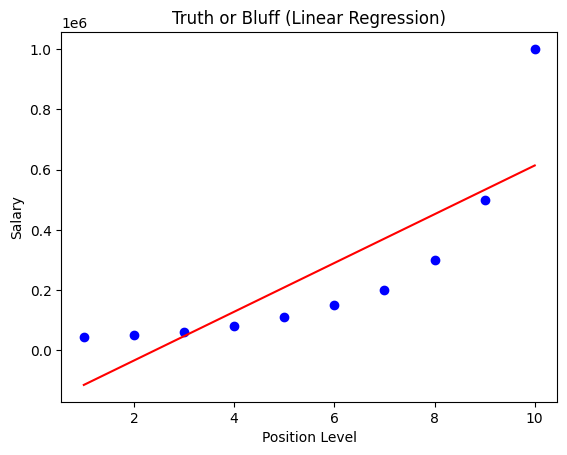

In [ ]:
plt.scatter(x, y, color ='blue')
plt.plot(x, lr.predict(x), color = 'red')
plt.title('Truth or Bluff (Linear Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

**Visualising the Polynomial Regression Rsults**

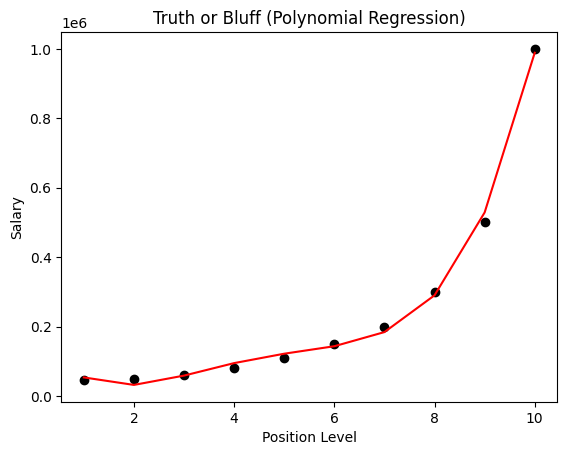

In [ ]:
plt.scatter(x, y, color ='black')
plt.plot(x, lin_reg_2.predict(pl.fit_transform(x)), color = 'red')
plt.title('Truth or Bluff (Polynomial Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

**Visualising the Polynomial Regression results(for higher resolution and smoother curve)**

In [ ]:

x_grid = np.arange(min(x), max(x), 0.1)
x_grid = x_grid.reshape((len(x_grid), 1))
plt.scatter(x, y, color ='black')
plt.plot(x_grid, lin_reg_2.predict(pl.fit_transform(x_grid)), color = 'red')
plt.title('Truth or Bluff (Polynomial Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.show()

TypeError: arange() not supported for inputs with DType <class 'numpy.dtypes.StrDType'>.

**Predicting a new result with Linear Regression**

In [ ]:
lr.predict([[6.5]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([330378.79])

**Predicting a new result with Polynomial Regression**

In [ ]:
lin_reg_2.predict(pl.fit_transform([[6.5]]))

array([158862.45])

**Logistic Regression**